In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [2]:
digits = load_digits()

X = digits.data      # Already flattened (64 features)
y = digits.target

print("Shape:", X.shape)


Shape: (1797, 64)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [5]:
components_list = [2, 10, 30, 50]

for n in components_list:
    pca = PCA(n_components=n)
    pca.fit(X_train_scaled)
    print(f"{n} components -> Explained Variance: {sum(pca.explained_variance_ratio_):.4f}")


2 components -> Explained Variance: 0.2170
10 components -> Explained Variance: 0.5898
30 components -> Explained Variance: 0.8933
50 components -> Explained Variance: 0.9833


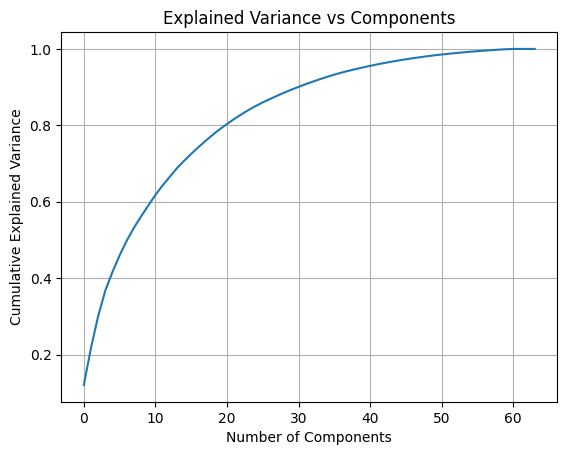

In [6]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure()
plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs Components")
plt.grid()
plt.show()


In [7]:
optimal_components = 30

pca = PCA(n_components=optimal_components)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Reduced Shape:", X_train_pca.shape)


Reduced Shape: (1437, 30)


In [8]:
lr_original = LogisticRegression(max_iter=5000)
lr_original.fit(X_train_scaled, y_train)

y_pred_original = lr_original.predict(X_test_scaled)

acc_original = accuracy_score(y_test, y_pred_original)
print("Original Accuracy:", acc_original)


Original Accuracy: 0.9722222222222222


In [9]:
lr_pca = LogisticRegression(max_iter=5000)
lr_pca.fit(X_train_pca, y_train)

y_pred_pca = lr_pca.predict(X_test_pca)

acc_pca = accuracy_score(y_test, y_pred_pca)
print("PCA Accuracy:", acc_pca)


PCA Accuracy: 0.9555555555555556


In [10]:
print("\nAccuracy Comparison")
print("----------------------")
print("Original Features:", acc_original)
print("PCA Reduced Features:", acc_pca)



Accuracy Comparison
----------------------
Original Features: 0.9722222222222222
PCA Reduced Features: 0.9555555555555556


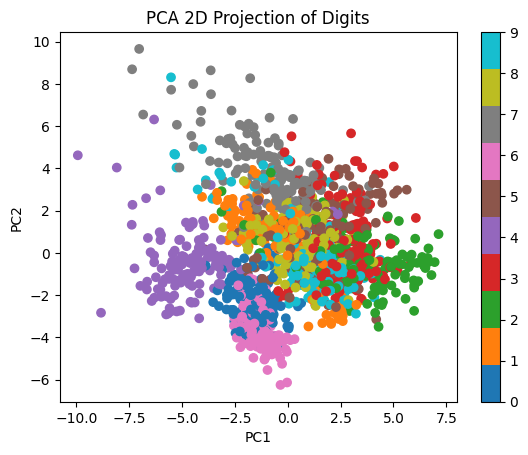

In [11]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure()
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_train, cmap="tab10")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D Projection of Digits")
plt.colorbar(scatter)
plt.show()


In [12]:
reduced_df = pd.DataFrame(X_train_pca)
reduced_df["label"] = y_train

reduced_df.to_csv("digits_pca_reduced.csv", index=False)


In [13]:
from google.colab import files
files.download("digits_pca_reduced.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>